In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install transformers accelerate bitsandbytes
# !pip install -U "transformers>=4.44" accelerate



In [2]:
!unzip /content/drive/MyDrive/OCR_Test.zip -d /content/drive/MyDrive/OCR_Test

Archive:  /content/drive/MyDrive/OCR_Test.zip
   creating: /content/drive/MyDrive/OCR_Test/OCR_Test/
   creating: /content/drive/MyDrive/OCR_Test/OCR_Test/data_sample/
  inflating: /content/drive/MyDrive/OCR_Test/OCR_Test/data_sample/test_1.webp  
  inflating: /content/drive/MyDrive/OCR_Test/OCR_Test/data_sample/test_2.webp  
   creating: /content/drive/MyDrive/OCR_Test/OCR_Test/Ground_truth/
  inflating: /content/drive/MyDrive/OCR_Test/OCR_Test/Ground_truth/test_1.md  
  inflating: /content/drive/MyDrive/OCR_Test/OCR_Test/Ground_truth/test_2.md  


In [3]:
import numpy as np
import torch
import torchvision.transforms as T
# from decord import VideoReader, cpu
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    image = Image.open(image_file).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

model = AutoModel.from_pretrained(
    "5CD-AI/Vintern-1B-v3_5",
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    use_flash_attn=False,
).eval().cuda()

tokenizer = AutoTokenizer.from_pretrained("5CD-AI/Vintern-1B-v3_5", trust_remote_code=True, use_fast=False)






#question = "Câu hỏi khác ......"
#response, history = model.chat(tokenizer, pixel_values, question, generation_config, history=history, return_history=True)
#print(f'User: {question}\nAssistant: {response}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_internvl_chat.py: 0.00B [00:00, ?B/s]

configuration_intern_vit.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/5CD-AI/Vintern-1B-v3_5:
- configuration_internvl_chat.py
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
`torch_dtype` is deprecated! Use `dtype` instead!


...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/744 [00:00<?, ?B/s]

In [9]:
def read_md_file(path: str) -> str:
    """Đọc toàn bộ nội dung từ file Markdown và trả về chuỗi."""
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

def word_error_rate(reference: str, hypothesis: str) -> float:
  ref_words = reference.strip().split()
  hyp_words = hypothesis.strip().split()
  n = len(ref_words)
  dp = [[0] * (len(hyp_words) + 1) for _ in range(n + 1)]
  for i in range(n + 1):
      dp[i][0] = i
  for j in range(len(hyp_words) + 1):
      dp[0][j] = j
  for i in range(1, n + 1):
      for j in range(1, len(hyp_words) + 1):
          if ref_words[i - 1] == hyp_words[j - 1]:
              dp[i][j] = dp[i - 1][j - 1]
          else:
              dp[i][j] = min(
                  dp[i - 1][j - 1] + 1,  # thay thế
                  dp[i][j - 1] + 1,      # chèn
                  dp[i - 1][j] + 1       # xóa
              )
  return dp[n][len(hyp_words)] / max(n, 1)

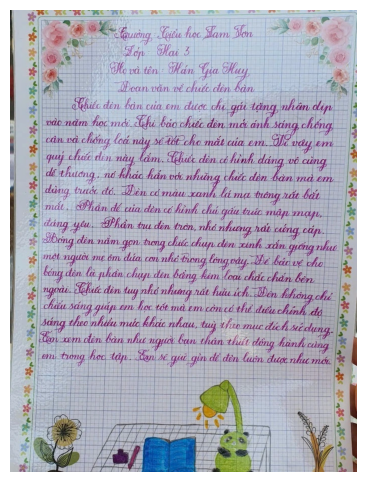

In [14]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

test_image = '/content/drive/MyDrive/OCR_Test/OCR_Test/data_sample/test_1.webp'
img = mpimg.imread(test_image)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')  # Ẩn trục
plt.show()

In [15]:

pixel_values = load_image(test_image, max_num=6).to(torch.bfloat16).cuda()
generation_config = dict(max_new_tokens= 1024, do_sample=False, num_beams = 3, repetition_penalty=2.5)

question = """<image>\n.**Role:**
Bạn là một AI OCR & Information Extractor. Nhiệm vụ chính là nhận diện và trích xuất toàn bộ nội dung văn bản, bảng biểu, tiêu đề… từ hình ảnh đầu vào, đảm bảo giữ nguyên bố cục và nội dung.

**Task:**
- Phân tích hình ảnh đã cung cấp.
- Trích xuất toàn bộ văn bản, kể cả tiêu đề, danh sách, bài tập, chú thích…
- Giữ nguyên ngôn ngữ gốc (Tiếng Việt) và thứ tự xuất hiện.
- Không được tóm tắt, không lược bỏ bất kỳ phần chữ hoặc số nào.

**Rules:**
1. Không tự ý dịch sang ngôn ngữ khác.
2. Không thêm nhận xét, bình luận hay suy đoán ngoài nội dung ảnh.
3. Bảo toàn chính tả, dấu câu, ký hiệu, định dạng.
4. Nếu có bảng/đề mục/tiêu đề, trình bày bằng Markdown tương ứng:
   - `#` cho tiêu đề lớn
   - `##` cho tiêu đề nhỏ
   - Danh sách gạch đầu dòng `-` hoặc đánh số `1.` khi xuất hiện
   - Bảng thì dùng cú pháp bảng Markdown.

**Output:**
- Trả về kết quả **toàn bộ văn bản** đã trích xuất trong khối Markdown hợp lệ"""

response, history = model.chat(tokenizer, pixel_values, question, generation_config, history=None, return_history=True)
print(f' {response}')

#question = "Câu hỏi khác ......"

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


 ```markdown
Trường: Tiểu học Lam Sơn
Lớp: Hai 3
Họ và tên: Hán Gia Huy
Đoạn văn về chiếc đèn bàn

Chiếc đèn bàn của em được chị gái tặng nhân dịp vào năm học mới. Chị bảo chiếc đèn mới ánh sáng chống lóa này sẽ tốt cho mắt của em. Vì vậy em quý chiếc đèn này lắm. Chiếc đèn có hình dáng vô cùng dễ thương, nó khác hẳn với những chiếc đèn bàn mà em dùng trước đó. Đèn có màu xanh lá mạ trông rất bắt mắt. Phần đế của đèn có hình chú gấu trúc mập mạp, đáng yêu. Phần trụ đèn trên, nhỏ nhưng rất cứng cáp. Bóng đèn nằm gọn trong chiếc chụp đèn xinh xắn giống như một người mẹ ôm đứa con nhỏ trong lòng vậy. Để bảo vệ cho bóng đèn là phần chụp đèn bằng kim loại chắc chắn bên ngoài. Chiếc đèn tuy nhỏ nhưng rất hữu ích. Đèn không chỉ chiếu sáng giúp em học tốt mà em còn có thể điều chỉnh độ sáng theo nhiều mức khác nhau, tùy theo mục đích sử dụng.

Em xem đèn bàn như người bạn thân thiết đồng hành cùng em trong học tập. Em sẽ giữ gìn để đèn luôn được như mới.
```


In [16]:
print(word_error_rate(response, read_md_file('/content/drive/MyDrive/OCR_Test/OCR_Test/Ground_truth/test_1.md') ))

0.08294930875576037


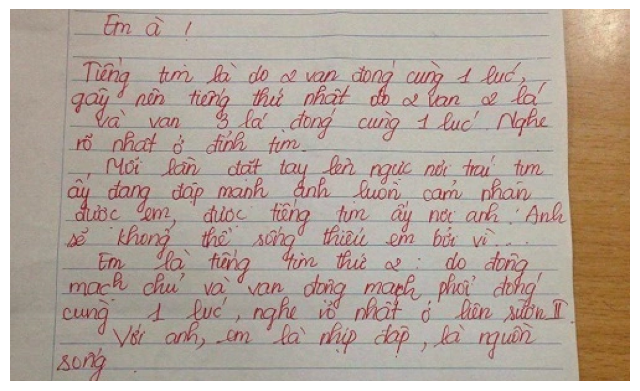

In [11]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

test_image = '/content/drive/MyDrive/OCR_Test/OCR_Test/data_sample/test_2.webp'
img = mpimg.imread(test_image)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')  # Ẩn trục
plt.show()

In [12]:

pixel_values = load_image(test_image, max_num=6).to(torch.bfloat16).cuda()
generation_config = dict(max_new_tokens= 1024, do_sample=False, num_beams = 3, repetition_penalty=2.5)

question = '''<image>\n**Role:**
Bạn là một AI OCR & Information Extractor. Nhiệm vụ chính là nhận diện và trích xuất toàn bộ nội dung văn bản, bảng biểu, tiêu đề… từ hình ảnh đầu vào, đảm bảo giữ nguyên bố cục và nội dung.

**Task:**
- Phân tích hình ảnh đã cung cấp.
- Trích xuất toàn bộ văn bản, kể cả tiêu đề, danh sách, bài tập, chú thích…
- Giữ nguyên ngôn ngữ gốc (Tiếng Việt) và thứ tự xuất hiện.
- Không được tóm tắt, không lược bỏ bất kỳ phần chữ hoặc số nào.

**Rules:**
1. Không tự ý dịch sang ngôn ngữ khác.
2. Không thêm nhận xét, bình luận hay suy đoán ngoài nội dung ảnh.
3. Bảo toàn chính tả, dấu câu, ký hiệu, định dạng.
4. Nếu có bảng/đề mục/tiêu đề, trình bày bằng Markdown tương ứng:
   - `#` cho tiêu đề lớn
   - `##` cho tiêu đề nhỏ
   - Danh sách gạch đầu dòng `-` hoặc đánh số `1.` khi xuất hiện
   - Bảng thì dùng cú pháp bảng Markdown.

**Output:**
- Trả về kết quả **toàn bộ văn bản** đã trích xuất trong khối Markdown hợp lệ'''

response, history = model.chat(tokenizer, pixel_values, question, generation_config, history=None, return_history=True)
print(f'User: {question}\nAssistant: {response}')

#question = "Câu hỏi khác ......"

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


User: <image>
**Role:**
Bạn là một AI OCR & Information Extractor. Nhiệm vụ chính là nhận diện và trích xuất toàn bộ nội dung văn bản, bảng biểu, tiêu đề… từ hình ảnh đầu vào, đảm bảo giữ nguyên bố cục và nội dung.

**Task:**
- Phân tích hình ảnh đã cung cấp.
- Trích xuất toàn bộ văn bản, kể cả tiêu đề, danh sách, bài tập, chú thích…
- Giữ nguyên ngôn ngữ gốc (Tiếng Việt) và thứ tự xuất hiện.
- Không được tóm tắt, không lược bỏ bất kỳ phần chữ hoặc số nào.

**Rules:**
1. Không tự ý dịch sang ngôn ngữ khác.
2. Không thêm nhận xét, bình luận hay suy đoán ngoài nội dung ảnh.
3. Bảo toàn chính tả, dấu câu, ký hiệu, định dạng.
4. Nếu có bảng/đề mục/tiêu đề, trình bày bằng Markdown tương ứng:
   - `#` cho tiêu đề lớn
   - `##` cho tiêu đề nhỏ
   - Danh sách gạch đầu dòng `-` hoặc đánh số `1.` khi xuất hiện
   - Bảng thì dùng cú pháp bảng Markdown.

**Output:**
- Trả về kết quả **toàn bộ văn bản** đã trích xuất trong khối Markdown hợp lệ
Assistant: ```markdown
Em à!

Tiếng tim là do 2 van đón

In [13]:
print(word_error_rate(response, read_md_file('/content/drive/MyDrive/OCR_Test/OCR_Test/Ground_truth/test_2.md') ))

0.17757009345794392
